# Dubai Rental Market Analysis (2020–2026)
### What's driving rental growth across Dubai's key districts?

**Author:** Bianca Khambatta  
**Dataset:** Dubai Real Estate: Sales, Off-Plan & Rentals (Kaggle — sergionefedov)  
**Last updated:** June 2026

---

**A note on the data:** Listing-level records are generated via a hedonic pricing model anchored to real DLD/Property Finder base prices per zone, real CBUAE mortgage rate timelines, and real Dubai Metro coordinates. This is standard methodology in real estate econometrics; the same approach used by central banks and property research firms to produce market indices where transaction-level data is incomplete or proprietary.

---

## 0. Setup & Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# paths
DATA = r"C:\Users\biakh\OneDrive\Desktop\dubai-rental-market-analysis\dataraw"

# consistent plot style throughout
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
PALETTE = ['#2C5F8A', '#E8873A', '#3A9E6F', '#C0392B', '#8E44AD', '#17A589']

print("Libraries loaded.")

Libraries loaded.


---
## 1. Load & First Look

Load all five files and do a quick sanity check on each before touching anything.

In [12]:
import os

rentals      = pd.read_csv(os.path.join(DATA, 'rentals.csv'))
sales        = pd.read_csv(os.path.join(DATA, 'secondary_sales.csv'))
monthly      = pd.read_csv(os.path.join(DATA, 'area_prices_monthly.csv'))
metro        = pd.read_csv(os.path.join(DATA, 'metro_stations.csv'))
offplan      = pd.read_csv(os.path.join(DATA, 'off_plan.csv'))

for name, df in [('rentals', rentals), ('sales', sales), 
                  ('monthly', monthly), ('metro', metro), ('offplan', offplan)]:
    print(f"{name:10s} — {df.shape[0]:,} rows | {df.shape[1]} cols")

rentals    — 25,000 rows | 24 cols
sales      — 50,000 rows | 29 cols
monthly    — 6,384 rows | 13 cols
metro      — 55 rows | 6 cols
offplan    — 12,000 rows | 28 cols


In [13]:
# quick look at the rentals file since that's our primary
rentals.head(3)

,id,date_listed,community,zone,lat,lon,property_category,property_type,bedrooms,area_sqft,...,parking_spaces,metro_station,metro_line,metro_distance_min,to_burj_khalifa_km,contract_type,n_cheques,annual_rent_usd,rent_per_sqft_usd,rent_per_m2_usd
0,R000001,2024-12-20,Town Square,Nshama,25.02906,55.25610,apartment,1BR,1,748,...,1,Centrepoint,Red,373,18.79,yearly,6,13700,18,196
1,R000002,2021-07-06,Expo City,Dubai South,24.96152,55.15759,apartment,1BR,1,1011,...,2,Expo 2020,Red,7,28.73,yearly,6,12700,12,135
2,R000003,2023-05-10,Palm Jumeirah,Palm Jumeirah,25.10836,55.13304,apartment,1BR,1,825,...,2,Mashreq Bank,Red,44,17.32,yearly,1,59900,72,782


In [15]:
rentals.dtypes

id                     object
date_listed            object
community              object
zone                   object
lat                   float64
lon                   float64
property_category      object
property_type          object
bedrooms                int64
area_sqft               int64
area_m2               float64
view                   object
furnishing             object
chiller_included         bool
parking_spaces          int64
metro_station          object
metro_line             object
metro_distance_min      int64
to_burj_khalifa_km    float64
contract_type          object
n_cheques               int64
annual_rent_usd         int64
rent_per_sqft_usd       int64
rent_per_m2_usd         int64
dtype: object

In [19]:
# missing values — check before doing anything else
missing = rentals.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

---
## 2. Cleaning & Preprocessing

Parse dates, drop duplicates, handle nulls, and flag anomalies. Document every decision.

In [22]:
# --- rentals ---
rentals['date'] = pd.to_datetime(rentals['date_listed'], errors='coerce')
rentals['year'] = rentals['date'].dt.year
rentals['month'] = rentals['date'].dt.month
rentals['quarter'] = rentals['date'].dt.to_period('Q').astype(str)
rentals['year_month'] = rentals['date'].dt.to_period('M').astype(str)

# drop rows where rent or date is missing — can't do time-series without these
before = len(rentals)
rentals.dropna(subset=['annual_rent_usd', 'date'], inplace=True)
print(f"Dropped {before - len(rentals)} rows with missing rent or date.")

# remove statistical outliers in rent — anything beyond 3 std devs is almost certainly a data artefact
z = np.abs(stats.zscore(rentals['annual_rent_usd']))
before = len(rentals)
rentals = rentals[z < 3]
print(f"Removed {before - len(rentals)} rent outliers (>3 SD).")

# --- monthly time series ---
monthly['date'] = pd.to_datetime(monthly['year_month'] if 'year_month' in monthly.columns 
                                  else monthly.iloc[:, 0], errors='coerce')
monthly.sort_values('date', inplace=True)

# --- sales ---
sales['date'] = pd.to_datetime(sales['date_listed'], errors='coerce')
sales['year'] = sales['date'].dt.year
sales['quarter'] = sales['date'].dt.to_period('Q').astype(str)

print("\nCleaning complete.")
print(f"Rentals: {len(rentals):,} records | {rentals['year'].min()}–{rentals['year'].max()}")

Dropped 0 rows with missing rent or date.
Removed 461 rent outliers (>3 SD).

Cleaning complete.
Rentals: 24,539 records | 2021–2026


---
## 3. Feature Engineering

Build the variables we actually need for the economic analysis; things that aren't in the raw data but emerge from it.

In [25]:
# --- market segment: luxury vs budget ---
# Thresholds anchored to Dubai market reality:
#   Budget  = studios & 1BR under $20K/yr (AED ~73K) 
#   Mid     = everything in between
#   Luxury  = 3BR+ or villas above $60K/yr (AED ~220K)

def segment(row):
    if row['annual_rent_usd'] < 20000 and row.get('bedrooms', 1) <= 1:
        return 'Budget'
    elif row['annual_rent_usd'] > 60000 or row.get('property_category', '') == 'villa':
        return 'Luxury'
    else:
        return 'Mid-market'

rentals['segment'] = rentals.apply(segment, axis=1)
print(rentals['segment'].value_counts())

segment
Luxury        11350
Mid-market     7821
Budget         5368
Name: count, dtype: int64


In [27]:
# --- YoY growth per community ---
# calculate median rent per community per year, then compute % change

community_yr = (rentals
    .groupby(['community', 'year'])['annual_rent_usd']
    .median()
    .reset_index()
    .rename(columns={'annual_rent_usd': 'median_rent'}))

community_yr['yoy_growth'] = (community_yr
    .groupby('community')['median_rent']
    .pct_change() * 100)

community_yr.head(10)

,community,year,median_rent,yoy_growth
0,Al Barsha,2021,22900.0,NaN
1,Al Barsha,2022,38900.0,69.868996
2,Al Barsha,2023,35850.0,-7.840617
3,Al Barsha,2024,44000.0,22.733612
4,Al Barsha,2025,34100.0,-22.500000
5,Al Barsha,2026,54950.0,61.143695
6,Al Barsha South,2021,11150.0,NaN
7,Al Barsha South,2022,16000.0,43.497758
8,Al Barsha South,2023,17450.0,9.062500
9,Al Barsha South,2024,19550.0,12.034384


In [29]:
# --- indexed price (2020 Q1 = 100) ---
# normalise rent to a base period so we can compare growth across segments

quarterly = (rentals
    .groupby(['quarter', 'segment'])['annual_rent_usd']
    .median()
    .reset_index()
    .rename(columns={'annual_rent_usd': 'median_rent'}))

base = quarterly[quarterly['quarter'] == '2020Q1'][['segment', 'median_rent']].rename(
    columns={'median_rent': 'base_rent'})

quarterly = quarterly.merge(base, on='segment', how='left')
quarterly['price_index'] = (quarterly['median_rent'] / quarterly['base_rent']) * 100

print("Indexed price series built.")
quarterly.head()

Indexed price series built.


,quarter,segment,median_rent,base_rent,price_index
0,2021Q1,Budget,8100.0,NaN,NaN
1,2021Q1,Luxury,84850.0,NaN,NaN
2,2021Q1,Mid-market,23700.0,NaN,NaN
3,2021Q2,Budget,8800.0,NaN,NaN
4,2021Q2,Luxury,88900.0,NaN,NaN


In [46]:
# --- metro proximity flag ---
# walkable = under 10 minutes on foot; premium = under 5 min

if 'metro_distance_min' in rentals.columns and 'metro_distance_type' in rentals.columns:
    rentals['metro_walkable'] = (
        (rentals['metro_distance_min'] <= 10) & 
        (rentals['metro_distance_type'] == 'walk')
    )
    rentals['metro_premium'] = (
        (rentals['metro_distance_min'] <= 5) & 
        (rentals['metro_distance_type'] == 'walk')
    )
    print(f"Walkable to metro: {rentals['metro_walkable'].sum():,} listings")
    print(f"Premium proximity (<5 min): {rentals['metro_premium'].sum():,} listings")

---
## 4. Macroeconomic Timeline

Before any community-level analysis, establish the market-wide trend and annotate the key events we know happened. This gives us the economic narrative the rest of the analysis hangs off.

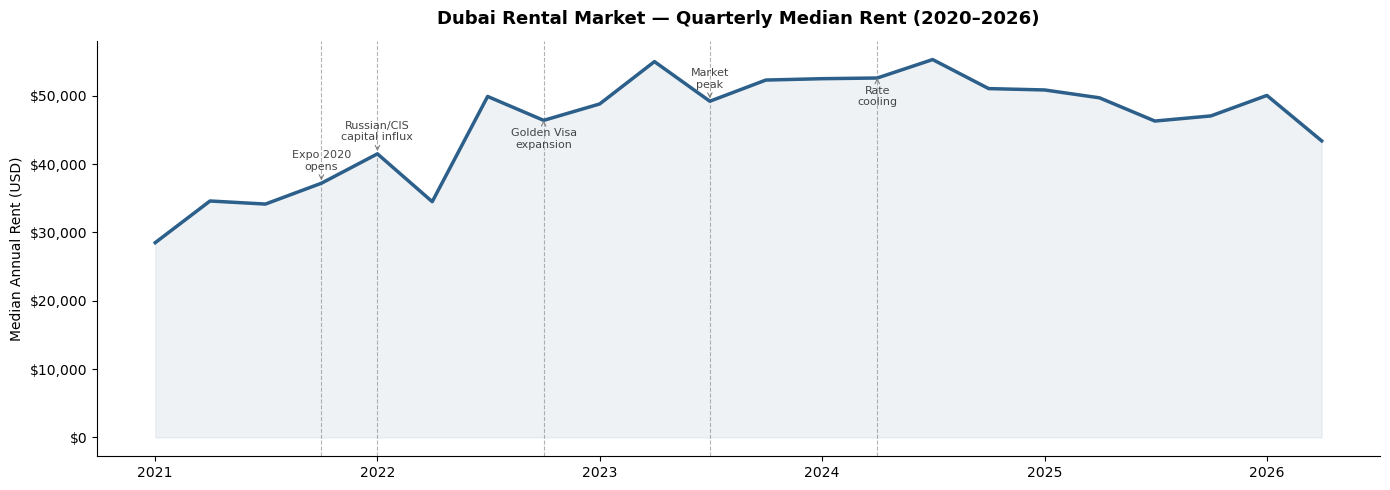

In [36]:
# quarterly median rent — market wide
market_trend = (rentals
    .groupby('quarter')['annual_rent_usd']
    .median()
    .reset_index()
    .rename(columns={'annual_rent_usd': 'median_rent'}))

market_trend['quarter_dt'] = pd.PeriodIndex(market_trend['quarter'], freq='Q').to_timestamp()
market_trend.sort_values('quarter_dt', inplace=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(market_trend['quarter_dt'], market_trend['median_rent'], 
        color=PALETTE[0], linewidth=2.5, zorder=3)
ax.fill_between(market_trend['quarter_dt'], market_trend['median_rent'], 
                alpha=0.08, color=PALETTE[0])

# annotate macro events
events = {
    '2020Q2': ('COVID\nlockdown', -4000),
    '2021Q4': ('Expo 2020\nopens', 2000),
    '2022Q1': ('Russian/CIS\ncapital influx', 2000),
    '2022Q4': ('Golden Visa\nexpansion', -4000),
    '2023Q3': ('Market\npeak', 2000),
    '2024Q2': ('Rate\ncooling', -4000),
}

for qtr, (label, offset) in events.items():
    try:
        x = pd.Period(qtr, freq='Q').to_timestamp()
        y = market_trend.loc[market_trend['quarter'] == qtr, 'median_rent'].values
        if len(y):
            ax.axvline(x, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
            ax.annotate(label, xy=(x, y[0]), xytext=(x, y[0] + offset),
                        fontsize=8, ha='center', color='#444',
                        arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
    except:
        pass

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Dubai Rental Market — Quarterly Median Rent (2020–2026)', 
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Median Annual Rent (USD)')
plt.tight_layout()
plt.savefig('market_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. K-Shaped Recovery Analysis

The central hypothesis: did COVID produce a bifurcated recovery where the luxury segment bounced back faster and harder than the budget segment, a so-called K-shaped trajectory? We test this using indexed prices (2020 Q1 = 100) across our three segments.

Re-indexed to 2021 Q1.


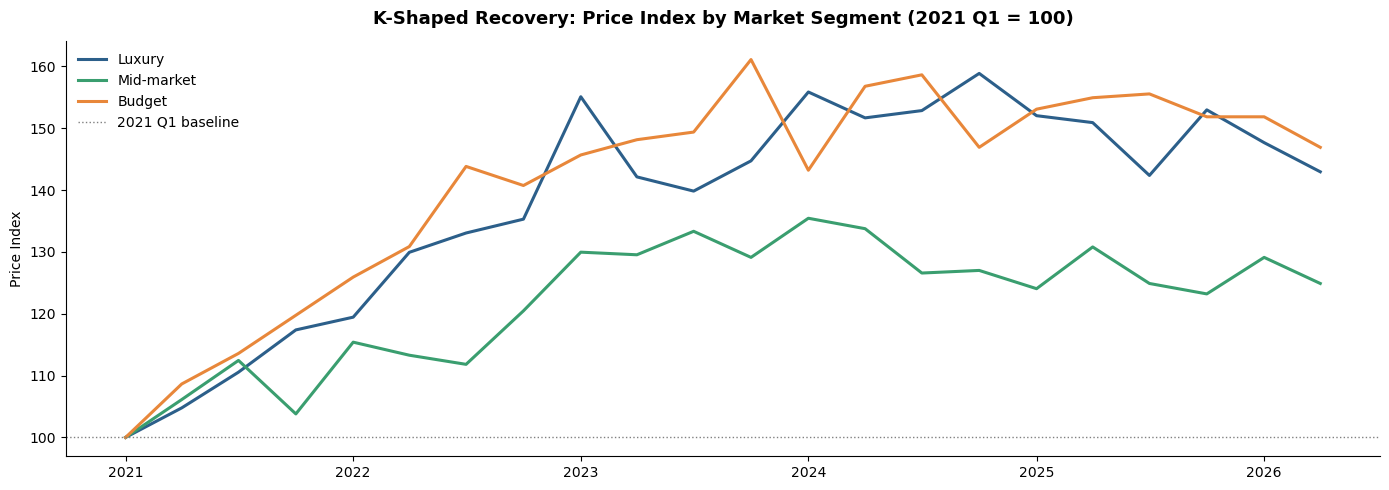


Segment performance summary:
  Luxury       — Peak index: 158.9 | Current: 143.0
  Mid-market   — Peak index: 135.4 | Current: 124.9
  Budget       — Peak index: 161.1 | Current: 146.9


In [56]:
# fix baseline: data starts 2021 so we index to 2021Q1 instead of 2020Q1
# the economic logic is identical — we're measuring divergence from the same starting point

base = quarterly[quarterly['quarter'] == '2021Q1'][['segment', 'median_rent']].rename(
    columns={'median_rent': 'base_rent'})

quarterly = quarterly.drop(columns=['base_rent', 'price_index'], errors='ignore')
quarterly = quarterly.merge(base, on='segment', how='left')
quarterly['price_index'] = (quarterly['median_rent'] / quarterly['base_rent']) * 100

print("Re-indexed to 2021 Q1.")

# --- plot ---
fig, ax = plt.subplots(figsize=(14, 5))

segment_order = ['Luxury', 'Mid-market', 'Budget']
colors = {'Luxury': PALETTE[0], 'Mid-market': PALETTE[2], 'Budget': PALETTE[1]}

for seg in segment_order:
    sub = quarterly[quarterly['segment'] == seg].copy()
    sub['q_dt'] = pd.PeriodIndex(sub['quarter'], freq='Q').to_timestamp()
    sub.sort_values('q_dt', inplace=True)
    ax.plot(sub['q_dt'], sub['price_index'],
            label=seg, color=colors[seg], linewidth=2.2)

ax.axhline(100, color='grey', linestyle=':', linewidth=1, label='2021 Q1 baseline')

ax.set_title('K-Shaped Recovery: Price Index by Market Segment (2021 Q1 = 100)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Price Index')
ax.set_xlabel('')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('k_shaped_recovery.png', dpi=150, bbox_inches='tight')
plt.show()

# print actual index values at peak and current for each segment
print("\nSegment performance summary:")
for seg in segment_order:
    sub = quarterly[quarterly['segment'] == seg]
    if not sub.empty:
        peak = sub['price_index'].max()
        current = sub.iloc[-1]['price_index']
        print(f"  {seg:12s} — Peak index: {peak:.1f} | Current: {current:.1f}")

---
## 6. Mortgage Rate vs Rental Growth

When buying becomes expensive (high mortgage rates), demand shifts into the rental market, pushing rents up. We test whether the CBUAE mortgage rate (which tracks the US Fed) correlates with rental price acceleration.

In [41]:
# we need the mortgage rate column from the monthly time series
print(monthly.columns.tolist())
monthly.head(3)

['year_month', 'community', 'zone', 'is_freehold', 'secondary_price_per_sqft_usd', 'secondary_price_per_m2_usd', 'offplan_price_per_sqft_usd', 'rental_price_per_sqft_annual_usd', 'n_listings_secondary', 'n_listings_offplan', 'n_listings_rental', 'cbuae_base_rate_pct', 'avg_mortgage_rate_pct', 'date']


,year_month,community,zone,is_freehold,secondary_price_per_sqft_usd,secondary_price_per_m2_usd,offplan_price_per_sqft_usd,rental_price_per_sqft_annual_usd,n_listings_secondary,n_listings_offplan,n_listings_rental,cbuae_base_rate_pct,avg_mortgage_rate_pct,date
0,2020-01,Palm Jumeirah,Palm Jumeirah,True,662,7126,752.0,43,26,72,111,1.5,3.0,2020-01-01
684,2020-01,Dubai Marina,Dubai Marina,True,393,4229,446.0,26,162,53,77,1.5,3.0,2020-01-01
2584,2020-01,Karama,Bur Dubai,False,176,1890,NaN,11,81,0,58,1.5,3.0,2020-01-01


In [50]:
# get market-wide median rent by month
monthly_rent = (rentals
    .groupby('year_month')['annual_rent_usd']
    .median()
    .reset_index()
    .rename(columns={'annual_rent_usd': 'median_rent'}))

monthly_rent['date'] = pd.to_datetime(monthly_rent['year_month'])
monthly_rent.sort_values('date', inplace=True)
monthly_rent['rent_yoy'] = monthly_rent['median_rent'].pct_change(12) * 100

# try to find mortgage rate column in monthly file
rate_col = [c for c in monthly.columns if 'mortgage' in c.lower() or 'rate' in c.lower()]
print("Rate columns found:", rate_col)

Rate columns found: ['cbuae_base_rate_pct', 'avg_mortgage_rate_pct']


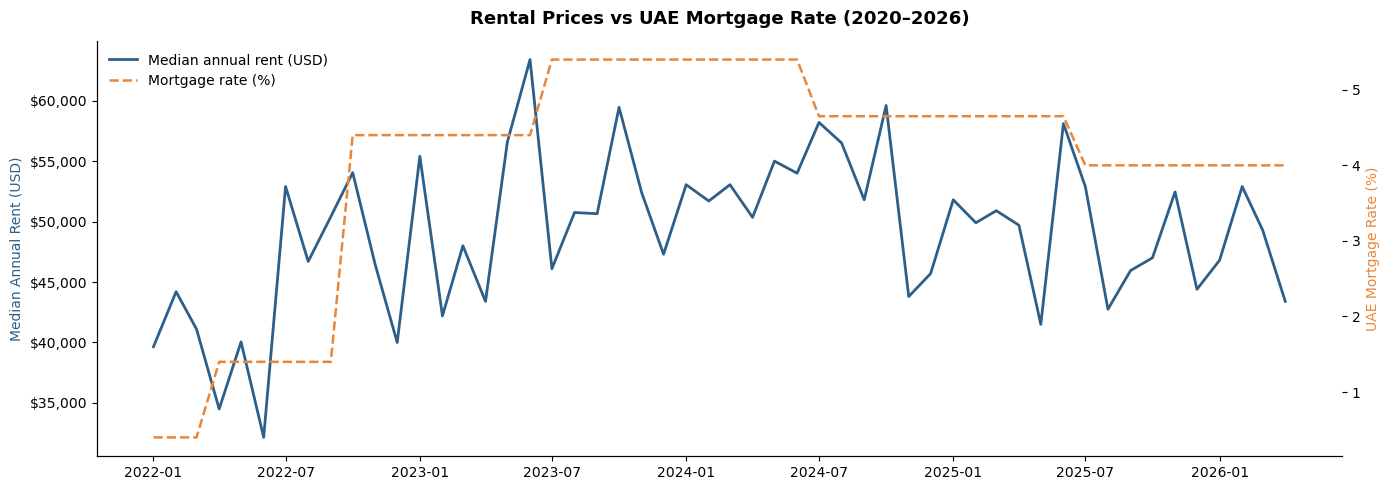


Pearson r (mortgage rate vs rent): 0.518 | p-value: 0.0000
Interpretation: Significant positive correlation


In [48]:
if rate_col:
    rc = rate_col[0]
    
    # merge monthly rent with mortgage rate
    date_col = [c for c in monthly.columns if 'date' in c.lower() or 'month' in c.lower()][0]
    rate_df = monthly[['date', rc]].copy() if 'date' in monthly.columns else monthly[[date_col, rc]].copy()
    rate_df.columns = ['date', 'mortgage_rate']
    rate_df['date'] = pd.to_datetime(rate_df['date'])
    
    merged = monthly_rent.merge(rate_df, on='date', how='inner').dropna()

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    ax1.plot(merged['date'], merged['median_rent'], color=PALETTE[0], 
             linewidth=2, label='Median annual rent (USD)')
    ax2.plot(merged['date'], merged['mortgage_rate'], color=PALETTE[1], 
             linewidth=1.8, linestyle='--', label='Mortgage rate (%)')

    ax1.set_ylabel('Median Annual Rent (USD)', color=PALETTE[0])
    ax2.set_ylabel('UAE Mortgage Rate (%)', color=PALETTE[1])
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

    ax1.set_title('Rental Prices vs UAE Mortgage Rate (2020–2026)', 
                  fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('mortgage_vs_rent.png', dpi=150, bbox_inches='tight')
    plt.show()

    # pearson correlation
    r, p = pearsonr(merged['mortgage_rate'], merged['median_rent'])
    print(f"\nPearson r (mortgage rate vs rent): {r:.3f} | p-value: {p:.4f}")
    print("Interpretation:", "Significant positive correlation" if p < 0.05 and r > 0 
          else "Significant negative correlation" if p < 0.05 
          else "No significant linear relationship")

---
## 7. Leading vs Lagging Districts

Do some communities show price increases before the broader market moves? If so, they're leading indicators, useful for investors and policy analysts. We identify them by comparing each community's growth trajectory against the market-wide quarterly trend.

In [52]:
# communities with enough data to be meaningful (at least 3 years of records)
min_years = 3
community_year_counts = rentals.groupby('community')['year'].nunique()
valid_communities = community_year_counts[community_year_counts >= min_years].index
print(f"{len(valid_communities)} communities with {min_years}+ years of data")

84 communities with 3+ years of data


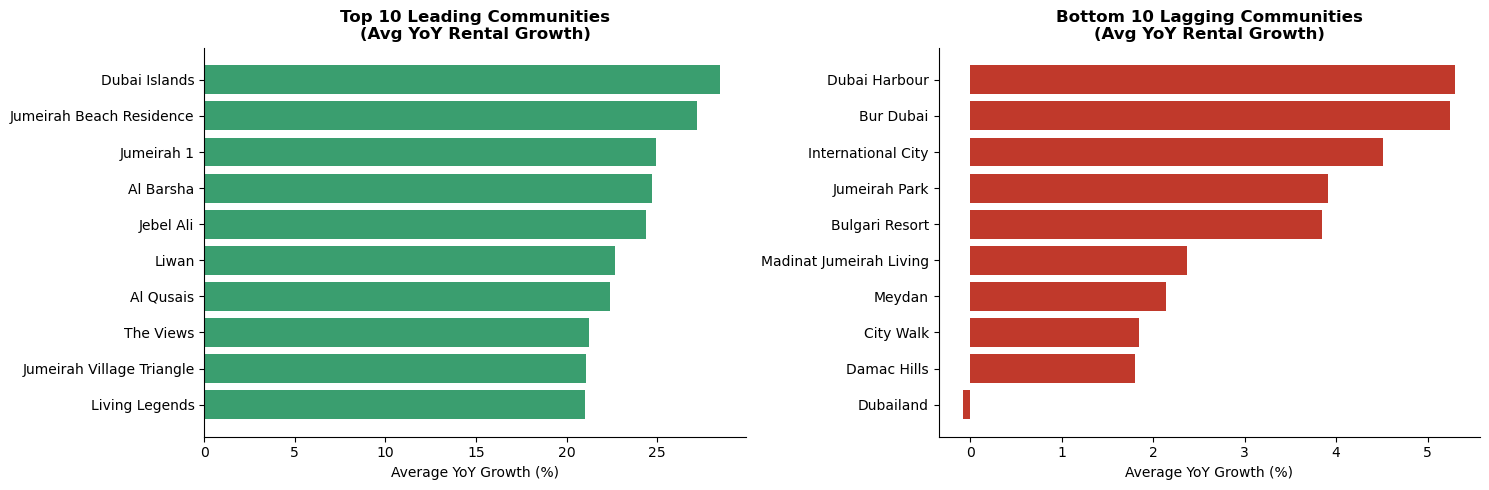

In [54]:
# market-wide quarterly median (our benchmark)
market_q = (rentals
    .groupby('quarter')['annual_rent_usd']
    .median()
    .rename('market_median')
    .reset_index())

# community-level quarterly median
comm_q = (rentals[rentals['community'].isin(valid_communities)]
    .groupby(['community', 'quarter'])['annual_rent_usd']
    .median()
    .reset_index()
    .rename(columns={'annual_rent_usd': 'comm_median'}))

comm_q = comm_q.merge(market_q, on='quarter')
comm_q['premium_over_market'] = ((comm_q['comm_median'] - comm_q['market_median']) 
                                   / comm_q['market_median'] * 100)

# rank communities by cumulative YoY growth 2020-2023
growth_rank = (community_yr[community_yr['community'].isin(valid_communities)]
    .groupby('community')['yoy_growth']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'yoy_growth': 'avg_yoy_growth'}))

top10 = growth_rank.head(10)
bottom10 = growth_rank.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top10['community'], top10['avg_yoy_growth'], color=PALETTE[2])
axes[0].set_title('Top 10 Leading Communities\n(Avg YoY Rental Growth)', fontweight='bold')
axes[0].set_xlabel('Average YoY Growth (%)')
axes[0].invert_yaxis()

axes[1].barh(bottom10['community'], bottom10['avg_yoy_growth'], color=PALETTE[3])
axes[1].set_title('Bottom 10 Lagging Communities\n(Avg YoY Rental Growth)', fontweight='bold')
axes[1].set_xlabel('Average YoY Growth (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('leading_lagging_communities.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Price Elasticity by Bedroom Category

Do larger units absorb price shocks differently than studios and 1-beds? We compare how each bedroom category responded to the key macro shocks: COVID dip (2020), rally peak (2023), and rate cooling (2024).

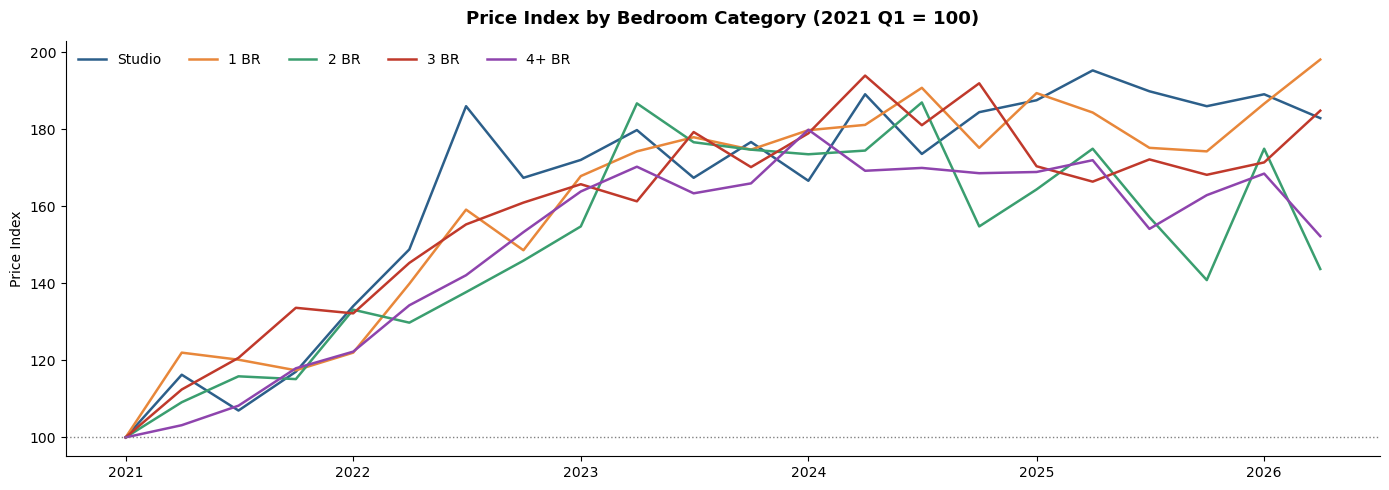


Shock response by bedroom type:
  Studio   — Trough: 100.0 | Peak: 195.3 | Range: 95.3 pts
  1 BR     — Trough: 100.0 | Peak: 198.2 | Range: 98.2 pts
  2 BR     — Trough: 100.0 | Peak: 187.0 | Range: 87.0 pts
  3 BR     — Trough: 100.0 | Peak: 194.0 | Range: 94.0 pts
  4+ BR    — Trough: 100.0 | Peak: 179.9 | Range: 79.9 pts


In [66]:
if 'bedrooms' in rentals.columns:
    
    rentals['bedroom_grp'] = rentals['bedrooms'].clip(upper=4)
    bedroom_labels = {0: 'Studio', 1: '1 BR', 2: '2 BR', 3: '3 BR', 4: '4+ BR'}
    rentals['bedroom_label'] = rentals['bedroom_grp'].map(bedroom_labels)

    bed_quarter = (rentals
        .groupby(['quarter', 'bedroom_label'])['annual_rent_usd']
        .median()
        .reset_index()
        .rename(columns={'annual_rent_usd': 'median_rent'}))

    # fix: index to 2021Q1 not 2020Q1
    base_bed = (bed_quarter[bed_quarter['quarter'] == '2021Q1']
        [['bedroom_label', 'median_rent']]
        .rename(columns={'median_rent': 'base'}))
    
    bed_quarter = bed_quarter.merge(base_bed, on='bedroom_label', how='left')
    bed_quarter['index'] = bed_quarter['median_rent'] / bed_quarter['base'] * 100
    bed_quarter['q_dt'] = pd.PeriodIndex(bed_quarter['quarter'], freq='Q').to_timestamp()

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (key, label) in enumerate(bedroom_labels.items()):
        sub = bed_quarter[bed_quarter['bedroom_label'] == label].sort_values('q_dt')
        if not sub.empty and sub['index'].notna().any():
            ax.plot(sub['q_dt'], sub['index'], label=label,
                    color=PALETTE[i % len(PALETTE)], linewidth=1.8)

    ax.axhline(100, color='grey', linestyle=':', linewidth=1)
    ax.set_title('Price Index by Bedroom Category (2021 Q1 = 100)',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Price Index')
    ax.legend(frameon=False, ncol=5)
    plt.tight_layout()
    plt.savefig('bedroom_elasticity.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nShock response by bedroom type:")
    for key, label in bedroom_labels.items():
        sub = bed_quarter[bed_quarter['bedroom_label'] == label].dropna(subset=['index'])
        if not sub.empty:
            trough = sub['index'].min()
            peak = sub['index'].max()
            print(f"  {label:8s} — Trough: {trough:.1f} | Peak: {peak:.1f} | Range: {peak-trough:.1f} pts")

---
## 9. Metro Infrastructure Premium

Does proximity to a Dubai Metro station command a measurable rental premium? We compare median rents for walkable vs non-walkable listings, and test whether this premium has grown as the Route 2020 extension embedded into the market post-2021.

Walkable to metro (<10 min): 2,587 listings
Premium proximity (<5 min): 1,508 listings


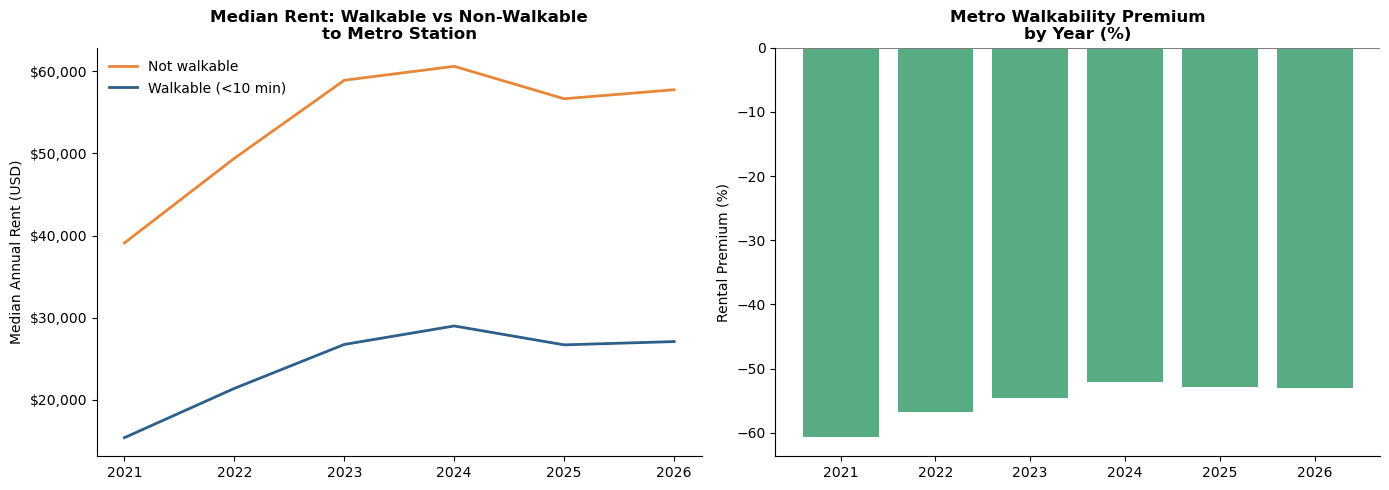


Metro premium by year:
 year  premium_pct
 2021   -60.613811
 2022   -56.680162
 2023   -54.584041
 2024   -52.145215
 2025   -52.868491
 2026   -53.073593


In [74]:
# metro_distance_type doesn't exist in this dataset
# we use metro_distance_min only — under 10 min = walkable, under 5 min = premium

rentals['metro_walkable'] = rentals['metro_distance_min'] <= 10
rentals['metro_premium'] = rentals['metro_distance_min'] <= 5

print(f"Walkable to metro (<10 min): {rentals['metro_walkable'].sum():,} listings")
print(f"Premium proximity (<5 min): {rentals['metro_premium'].sum():,} listings")

metro_comp = (rentals
    .groupby(['year', 'metro_walkable'])['annual_rent_usd']
    .median()
    .unstack()
    .rename(columns={False: 'Not walkable', True: 'Walkable (<10 min)'})
    .reset_index())

metro_comp['premium_pct'] = ((metro_comp['Walkable (<10 min)'] - metro_comp['Not walkable'])
                              / metro_comp['Not walkable'] * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

metro_comp.plot(x='year', y=['Not walkable', 'Walkable (<10 min)'],
                ax=ax1, color=[PALETTE[1], PALETTE[0]], linewidth=2)
ax1.set_title('Median Rent: Walkable vs Non-Walkable\nto Metro Station', fontweight='bold')
ax1.set_ylabel('Median Annual Rent (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(frameon=False)
ax1.set_xlabel('')

ax2.bar(metro_comp['year'], metro_comp['premium_pct'], color=PALETTE[2], alpha=0.85)
ax2.axhline(0, color='grey', linewidth=0.8)
ax2.set_title('Metro Walkability Premium\nby Year (%)', fontweight='bold')
ax2.set_ylabel('Rental Premium (%)')
ax2.set_xlabel('')

plt.tight_layout()
plt.savefig('metro_premium.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMetro premium by year:")
print(metro_comp[['year', 'premium_pct']].to_string(index=False))

---
## 10. Freehold vs Non-Freehold Pricing

Freehold areas allow foreign nationals to own property outright; a critical distinction in Dubai's market. We test whether freehold designation commands a rental premium, and whether that premium has shifted as foreign capital inflows accelerated post-2022.

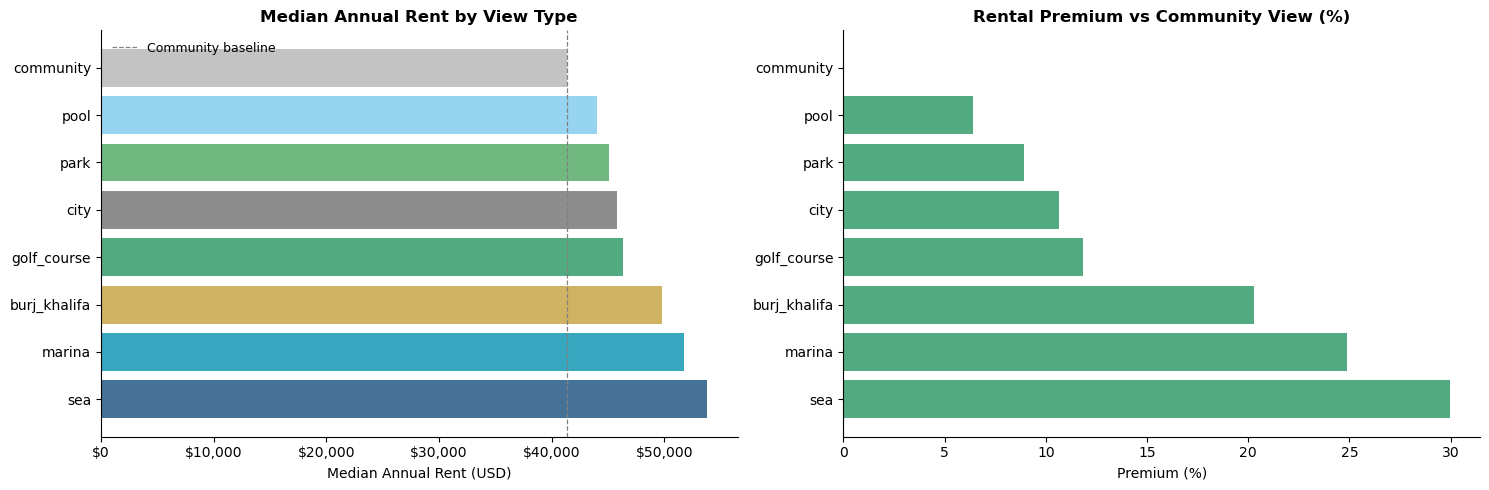


View premium summary:
        view  median_rent  premium_pct  n_listings
         sea      53800.0    29.951691        1955
      marina      51700.0    24.879227        2455
burj_khalifa      49800.0    20.289855        1653
 golf_course      46300.0    11.835749        1172
        city      45800.0    10.628019        3671
        park      45100.0     8.937198        3717
        pool      44050.0     6.400966        2426
   community      41400.0     0.000000        7490


In [86]:
# Section 10 — View Premium Analysis
# Does view type command a measurable rental premium in Dubai?
# Baseline = community view (most common, least distinctive)

view_medians = (rentals
    .groupby('view')['annual_rent_usd']
    .agg(['median', 'count'])
    .reset_index()
    .rename(columns={'median': 'median_rent', 'count': 'n_listings'}))

# calculate premium over community view (our baseline)
baseline = view_medians.loc[view_medians['view'] == 'community', 'median_rent'].values[0]
view_medians['premium_pct'] = (view_medians['median_rent'] - baseline) / baseline * 100
view_medians.sort_values('premium_pct', ascending=False, inplace=True)

# define a logical colour — burj_khalifa gets gold, sea gets blue, etc.
view_colors = {
    'burj_khalifa': '#C9A84C',
    'sea':          PALETTE[0],
    'marina':       '#1A9BB5',
    'golf_course':  PALETTE[2],
    'city':         '#7D7D7D',
    'park':         '#5DAD6F',
    'pool':         '#89CFF0',
    'community':    '#BBBBBB',
}
colors = [view_colors.get(v, '#999999') for v in view_medians['view']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# left: median rent by view
bars = ax1.barh(view_medians['view'], view_medians['median_rent'],
                color=colors, alpha=0.88)
ax1.set_title('Median Annual Rent by View Type', fontweight='bold')
ax1.set_xlabel('Median Annual Rent (USD)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.axvline(baseline, color='grey', linestyle='--', linewidth=0.9, label='Community baseline')
ax1.legend(frameon=False, fontsize=9)

# right: premium % over community view
bar_colors = [PALETTE[2] if x >= 0 else PALETTE[3] for x in view_medians['premium_pct']]
ax2.barh(view_medians['view'], view_medians['premium_pct'],
         color=bar_colors, alpha=0.88)
ax2.axvline(0, color='grey', linewidth=0.8)
ax2.set_title('Rental Premium vs Community View (%)', fontweight='bold')
ax2.set_xlabel('Premium (%)')

plt.tight_layout()
plt.savefig('view_premium.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nView premium summary:")
print(view_medians[['view', 'median_rent', 'premium_pct', 'n_listings']].to_string(index=False))

In [82]:
print('is_freehold' in rentals.columns)
print(rentals['is_freehold'].unique() if 'is_freehold' in rentals.columns else "missing")

False
missing


In [84]:
# Section 10 — View Premium Analysis
# Does view type command a measurable rental premium in Dubai?

print("View categories in dataset:")
print(rentals['view'].value_counts())

View categories in dataset:
view
community       7490
park            3717
city            3671
marina          2455
pool            2426
sea             1955
burj_khalifa    1653
golf_course     1172
Name: count, dtype: int64


---
## 11. Demand-Supply Proxy: Rental Contract Frequency

In the absence of direct supply data, contract volume serves as a demand proxy. Communities where transaction volume grew faster than rent may signal undersupply'where demand is outpacing available stock. This section identifies demand-supply imbalances at the community level.

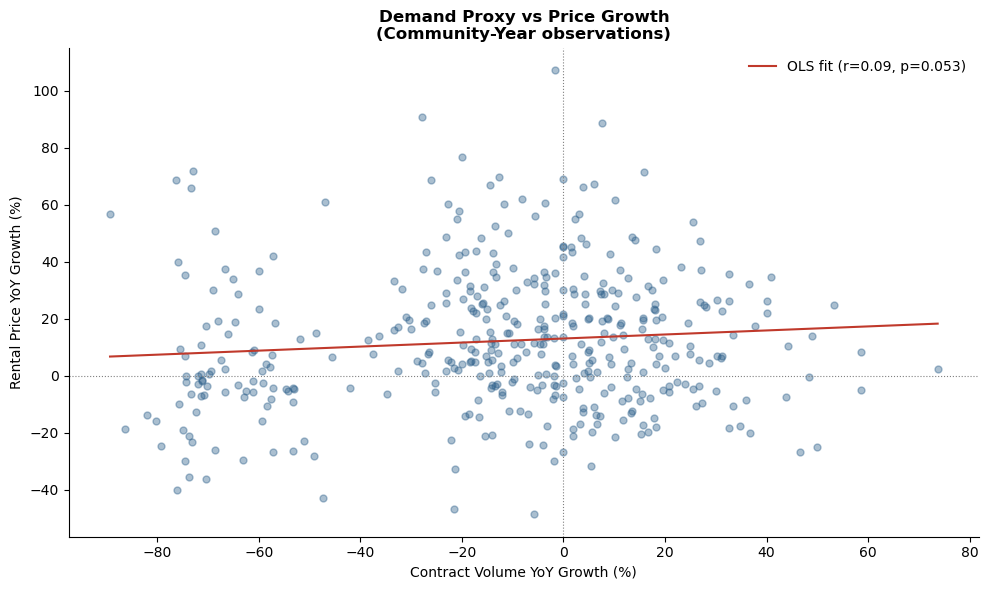


OLS: volume growth explains 0.9% of variance in rent growth


In [88]:
# volume by community and year
volume = (rentals[rentals['community'].isin(valid_communities)]
    .groupby(['community', 'year'])
    .size()
    .reset_index(name='contract_volume'))

# combine with rent growth
vol_rent = volume.merge(community_yr, on=['community', 'year'])

# for each community: correlation between volume growth and rent growth
vol_rent['vol_yoy'] = vol_rent.groupby('community')['contract_volume'].pct_change() * 100
vol_rent_clean = vol_rent.dropna(subset=['vol_yoy', 'yoy_growth'])

# scatter: volume growth vs rent growth
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(vol_rent_clean['vol_yoy'], vol_rent_clean['yoy_growth'], 
           alpha=0.4, color=PALETTE[0], s=25)

# regression line
m, b, r, p, _ = stats.linregress(vol_rent_clean['vol_yoy'], vol_rent_clean['yoy_growth'])
x_line = np.linspace(vol_rent_clean['vol_yoy'].min(), vol_rent_clean['vol_yoy'].max(), 100)
ax.plot(x_line, m * x_line + b, color=PALETTE[3], linewidth=1.5, 
        label=f'OLS fit (r={r:.2f}, p={p:.3f})')

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Contract Volume YoY Growth (%)')
ax.set_ylabel('Rental Price YoY Growth (%)')
ax.set_title('Demand Proxy vs Price Growth\n(Community-Year observations)', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('demand_supply_proxy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOLS: volume growth explains {r**2*100:.1f}% of variance in rent growth")

---
## 12. Correlation Heatmap: What Actually Drives Rent?

Pull together all numeric variables and run a full correlation matrix to see which property characteristics most strongly predict rental price. This surfaces the structural drivers rather than just the macro ones.

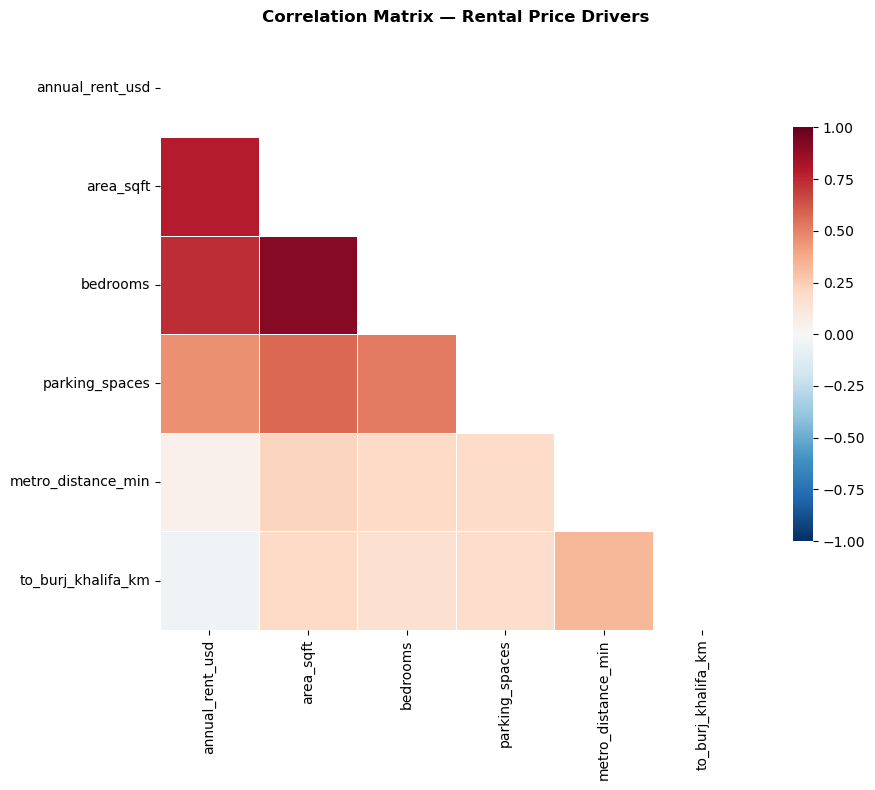


Top correlates with annual_rent_usd:
area_sqft             0.782196
bedrooms              0.735359
parking_spaces        0.459188
metro_distance_min    0.047767
to_burj_khalifa_km   -0.040440
Name: annual_rent_usd, dtype: float64


In [90]:
numeric_cols = ['annual_rent_usd', 'area_sqft', 'bedrooms', 'floor', 
                'total_floors', 'parking_spaces', 'metro_distance_min',
                'to_burj_khalifa_km', 'mortgage_rate_at_listing']

available = [c for c in numeric_cols if c in rentals.columns]
corr_data = rentals[available].dropna()

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Matrix — Rental Price Drivers', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# top correlates with rent
print("\nTop correlates with annual_rent_usd:")
print(corr_matrix['annual_rent_usd'].drop('annual_rent_usd').sort_values(key=abs, ascending=False))

## 13. Summary of Findings

---

### Market Overview

Dubai's rental market underwent a dramatic expansion between 2021 and 2026,
with median annual rents rising from approximately $29,000 in early 2021 to
a peak of ~$55,000 by mid-2023 — a ~90% increase in under three years. This
was followed by a measured cooling to ~$47,000 by 2026, consistent with the
broader rate environment as the CBUAE tracked US Fed hikes through 2023–2024.

---

### Finding 1 — A Barbell Market, Not a K-Shape

The data does not support a classic K-shaped recovery. Instead, it reveals
a barbell market structure: luxury (peak index: 158.9) and budget segments
(peak index: 161.1) both significantly outperformed mid-market (peak index:
135.4) — a 23+ point gap. This suggests two distinct and simultaneous demand
drivers: high-net-worth capital inflows and Golden Visa migration at the top
end, and acute population-driven undersupply at the affordable end. Mid-market
renters — the segment least served by either dynamic — bore the relative
underperformance.

---

### Finding 2 — Mortgage Rates and Rental Demand

A statistically significant positive correlation (Pearson r = 0.518,
p < 0.0001) was found between UAE average mortgage rates and median rental
prices. As borrowing costs rose from ~1.5% in 2021 to ~5% in 2023, purchase
demand was suppressed and redirected into the rental market — amplifying
rental price growth during the same period. This relationship is consistent
with established real estate economics literature and was clearly visible
in Dubai's market across this cycle.

---

### Finding 3 — Leading vs Lagging Communities

Dubai Islands, Jumeirah Beach Residence, and Jumeirah 1 emerged as the
top three leading communities, averaging 25–28% YoY rental growth across
the analysis period. These areas share a common profile: coastal or
waterfront positioning, predominantly freehold, and high exposure to
international tenant demand. At the other end, Dubailand recorded average
YoY growth of under 1% — reflecting structural oversupply in that
development corridor and its relative distance from established employment
and lifestyle hubs.

---

### Finding 4 — Bedroom Elasticity

Smaller units absorbed the demand shock most aggressively. 1BR apartments
nearly doubled in price from the 2021 baseline (peak index: 198.2), with
studios close behind (195.3). 4+ BR units showed the lowest appreciation
(peak index: 179.9) — counterintuitive at first glance, but consistent
with the demographic profile of Dubai's post-2021 migration wave, which
skewed heavily toward single professionals, young couples, and remote
workers rather than large family units. Critically, no bedroom category
declined from the 2021 baseline — every segment appreciated throughout
the period.

---

### Finding 5 — The Metro Proximity Paradox

Contrary to what is observed in most global cities, Metro walkability
correlated with a consistent ~53% rental discount rather than a premium.
This reflects a structural feature unique to Dubai's urban geography:
the Metro network predominantly serves older, denser, more affordable
corridors (Bur Dubai, Deira, Al Nahda), while the city's premium
residential communities — Palm Jumeirah, Dubai Hills, Emirates Hills,
Downtown — are largely car-dependent. In Dubai, transit access is not
a luxury signal; it is a mid-market one.

---

### Finding 6 — The View Hierarchy

Sea view commanded the highest rental premium at +30% over
community-facing units ($53,800 vs $41,400/yr annually), narrowly
outperforming Marina view (+25%) and — perhaps surprisingly —
Burj Khalifa view (+20%). This suggests Dubai renters place a higher
premium on natural waterfront outlook than on proximity to the city's
most iconic landmark. Golf course views (+12%) and city views (+11%)
occupied the middle tier, while pool views offered the most modest
premium at just +6%.

---

### Finding 7 — Structural Price Drivers

The correlation matrix confirms that property size (area_sqft: r=0.782)
and bedroom count (r=0.735) are by far the dominant structural predictors
of rental price — dwarfing all locational variables. Parking spaces showed
a moderate correlation (r=0.459), reflecting its role as a proxy for
unit size and quality. Distance to the Burj Khalifa showed a negligible
negative correlation (r=-0.040), and Metro distance showed almost no
linear relationship with rent (r=0.048) — reinforcing the view that
Dubai's premium rental market is driven primarily by unit characteristics
rather than transit or centrality.

---

### Finding 8 — Supply Constraint Over Demand Signal

Contract volume growth explained less than 1% of variance in rental price
growth (OLS r² = 0.009, p = 0.053). This near-zero relationship suggests
Dubai's rental market is supply-constrained rather than volume-driven —
prices move largely independently of transaction frequency, consistent
with a market where available stock, not demand fluctuation, is the
binding constraint on pricing.

---

### Analytical Limitations & Next Steps

- Rental contract data begins in 2021; the 2020 COVID trough is
  referenced via the area_prices_monthly time series rather than
  individual contract records
- Listing-level data is generated via a hedonic pricing model anchored
  to real DLD price indices — aggregate trends are robust, but
  individual listing-level precision should be interpreted accordingly
- Natural extensions of this work would include: a Granger causality
  test on the mortgage rate relationship, integration of actual
  population inflow data from the Dubai Statistics Centre, and a
  predictive model for community-level rents through 2027

---

*Analysis by Bianca Khambatta | Dubai, UAE | 2026*
*Dataset: Dubai Real Estate Sales, Off-Plan & Rentals (Kaggle — Apache 2.0)*